# 3. Particles: Sub-Regions of a Point Population

On an AMR grid a region boundary is a *choice*. A cell straddling the edge can
be kept whole, judged by its centre, or split by volume fraction, and the
[hydro page](03_hydro_Get_Subregions.md) is largely about the consequences of
that choice.

For particles there is no choice to make. A star is a point: it is inside the
region or it is outside, and `msum` over the selection is exact by
construction. There is no `:fraction` column, no `split` keyword, no
whole-cell/centre-test trade-off — the arithmetic that took the hydro page
several sections to make trustworthy is free here.

What is *not* free is the counting. A region that selects exactly can still
select almost nothing, and a mass built from eleven particles is exact and
useless at the same time. So this page keeps the same region vocabulary and
changes the question: not *how is the boundary treated*, but *how many
particles did this region actually catch, and what does that let me claim*.

**Reading convention.** Longer code cells are cut in two by a banner line:

```
# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
```

Everything above the banner is the Mera part; everything below is Makie
decoration.

**On this page**

1. points, not cells
2. one sphere, and arithmetic that cannot drift
3. what replaces the boundary error: counting
4. the geometry gallery
5. composites and the `@region` block
6. place *and* state: regions meet filters
7. profiles that regions make easy
8. reference: the classic symbol API
9. practical guidance


## 1. Points, Not Cells

The same galaxy as the hydro and gravity pages, seen through its star
particles. Each carries a position, a velocity, a mass, and a birth time —
that last column is what makes §6 and §7 possible.


In [1]:
# Example-data root. Point this at your own simulation folder, or set the
# MERA_EXAMPLES environment variable; every path below is built from it.
MERA_EXAMPLES = get(ENV, "MERA_EXAMPLES", "/Volumes/FASTStorage/Simulations/Mera-Tests");

using Mera, CairoMakie
# Makie also exports geometric names (Sphere, Cylinder, ...) — state explicitly
# that we mean Mera's region types:
import Mera: Sphere, Cuboid, Cylinder, SphericalShell, CylindricalShell
CairoMakie.activate!()

path = "$MERA_EXAMPLES/RAMSES/manu_sim_sf_L14"
info = getinfo(400, path, verbose=false)

stars = getparticles(info, verbose=false, show_progress=false)

kpc = info.scale.kpc
age = getvar(stars, :age, :Myr)

println("particles      : ", length(stars.data), "   columns: ", keys(stars.data[1]))
println("with birth = 0 : ", count(iszero, getvar(stars, :birth)), " (dark matter, if any)")
println("total mass     : ", round(msum(stars, :Msol), sigdigits=5), " Msol")
println("particle mass  : ", round(minimum(getvar(stars, :mass, :Msol)), sigdigits=3), " – ",
        round(maximum(getvar(stars, :mass, :Msol)), sigdigits=3), " Msol")
println("ages           : ", round(minimum(age), digits=1), " – ",
        round(maximum(age), digits=1), " Myr")
println("box            : ", round(stars.boxlen * kpc, sigdigits=4), " kpc")



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



particles      : 508939

   columns: (:level, :x, :y, :z, :id, :vx, :vy, :vz, :mass, :birth)
with birth = 0 : 0 (dark matter, if any)
total mass     : 5.8044e9 Msol
particle mass  : 4910.0

 – 22700.0 Msol
ages           : 0.0 – 531.0 Myr
box            : 48.0 kpc


Every particle loaded here carries a non-zero birth time — this population is
stars. Their combined mass, $5.8 \times 10^9\,M_\odot$, is worth remembering:
the [gravity page](03_gravity_Get_Subregions.md) measures a dynamical mass ten
times larger in the same volume, so whatever dominates this galaxy's potential
is not in this file.

The ages matter for §6 and §7, so note their range now: **every star here
formed during the run**, so the population spans zero to about 530 Myr and
nothing is older. "Old" on this page therefore means *a few hundred Myr*, not
a Hubble time — the contrasts below are between stars that formed in the last
few tens of Myr and stars that have had a few disc orbits to settle.


In [2]:
# ─────────────────────────────────────────────────────────────────────
# FIGURE INFRASTRUCTURE for the whole page — skim freely on first read.
# The one Mera-relevant definition is `sproj`: the projection defaults every
# stellar surface-density map reuses.
# ─────────────────────────────────────────────────────────────────────
const SDLIM = (-1.0, 3.0)   # log10 Σ* [Msol/pc²]

sproj(p; kwargs...) = projection(p, :sd, :Msol_pc2; direction=:z, center=[:bc],
                                 pxsize=[0.2, :kpc], verbose=false, show_progress=false,
                                 kwargs...)

function show_sd!(ax, p; flo=1e-2, decorate=false)
    m  = p.maps[:sd]
    xs = range(p.cextent[1]*kpc, p.cextent[2]*kpc; length=size(m, 1))
    ys = range(p.cextent[3]*kpc, p.cextent[4]*kpc; length=size(m, 2))
    heatmap!(ax, xs, ys, log10.(max.(m, flo)); colormap=:inferno, colorrange=SDLIM)
    ax.aspect = DataAspect()
    ax.backgroundcolor = :black
    decorate || hidedecorations!(ax)
    return ax
end

sd_bar!(pos) = Colorbar(pos; colormap=:inferno, colorrange=SDLIM,
                        label="log₁₀ Σ⋆  [Msol pc⁻²]")

# positions of a particle object, in kpc relative to the box centre
pos(o) = (getvar(o, :x, :kpc, center=[:bc]),
          getvar(o, :y, :kpc, center=[:bc]),
          getvar(o, :z, :kpc, center=[:bc]))


pos (generic function with 1 method)

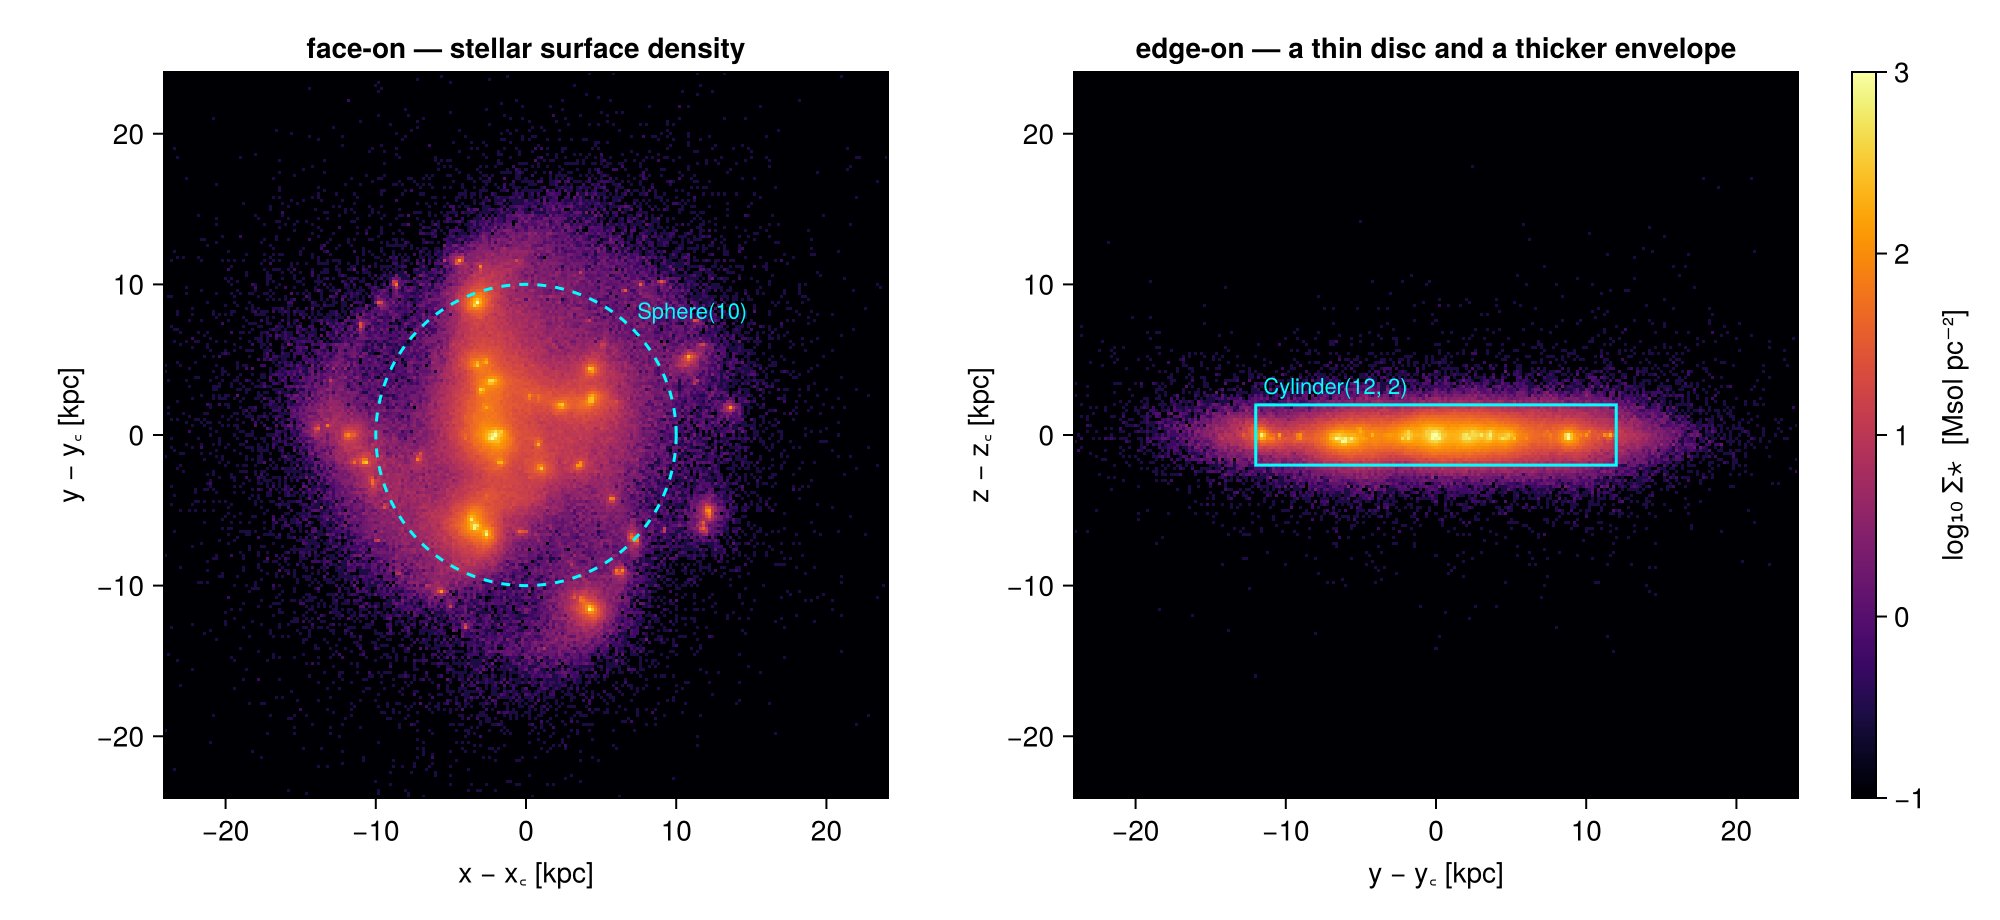

In [3]:
p_face = sproj(stars)
p_edge = sproj(stars; direction=:x)


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1000, 460))
axf = Axis(fig[1, 1], title="face-on — stellar surface density",
           xlabel="x − x꜀ [kpc]", ylabel="y − y꜀ [kpc]")
show_sd!(axf, p_face; decorate=true)
arc!(axf, Point2f(0, 0), 10., 0, 2π; color=:cyan, linewidth=1.5, linestyle=:dash)
text!(axf, 7.4, 7.4; text="Sphere(10)", color=:cyan, fontsize=11)

axe = Axis(fig[1, 2], title="edge-on — a thin disc and a thicker envelope",
           xlabel="y − y꜀ [kpc]", ylabel="z − z꜀ [kpc]")
show_sd!(axe, p_edge; decorate=true)
lines!(axe, [-12., 12., 12., -12., -12.], [-2., -2., 2., 2., -2.];
       color=:cyan, linewidth=1.5)
text!(axe, -11.5, 2.4; text="Cylinder(12, 2)", color=:cyan, fontsize=11)
sd_bar!(fig[1, 3])
fig


## 2. One Sphere, and Arithmetic That Cannot Drift

`subregion` takes the same region values as everywhere else. What it returns
is a particle object holding a *subset of the rows* — nothing is weighted,
nothing is partial.

Two consequences worth checking rather than assuming: a region and its
complement partition the population exactly, and adjacent regions add.


In [4]:
sph  = Sphere(10.)                       # center=[:bc], range_unit=:kpc by default
s_in  = subregion(stars, sph, verbose=false)
s_out = subregion(stars, sph, inverse=true, verbose=false)

N, M = length(stars.data), msum(stars, :Msol)
println("all particles      : ", rpad(N, 9), round(M, sigdigits=8), " Msol")
println("inside  Sphere(10) : ", rpad(length(s_in.data), 9),  round(msum(s_in, :Msol),  sigdigits=8))
println("outside Sphere(10) : ", rpad(length(s_out.data), 9), round(msum(s_out, :Msol), sigdigits=8))
println()
println("count residual : ", length(s_in.data) + length(s_out.data) - N)
println("mass  residual : ", (msum(s_in, :Msol) + msum(s_out, :Msol)) / M - 1,
        "   (floating-point summation only)")


all particles      : 508939   

5.804426e9 Msol
inside  Sphere(10) : 419529   4.7852795e9
outside Sphere(10) : 89410    1.0191465e9

count residual : 0
mass  residual : 1.5543122344752192e-15   (floating-point summation only)


The counts close on the nose — they are integers, and every particle is
classified exactly once. The mass residual is a few units in the last place:
not a boundary effect, just the order in which floating-point additions
happen.

That is the whole story of exactness for particles, and it is worth
appreciating how much cheaper it is than the grid version. The hydro page
needed volume fractions on every boundary cell to make a budget balance; here
additivity is a property of set membership.


## 3. What Replaces the Boundary Error: Counting

The error that *does* appear grows as regions get smaller. A population of
points sampled in a shell gives a mass with a statistical uncertainty of
roughly $M/\sqrt{N}$ — nothing to do with geometry, everything to do with how
many particles the shell caught.

The table below walks a stack of spherical shells outward. Watch the count
column, not the mass column.


shell [kpc]   N        

M [Msol]     ≈ 1/√N
----------------------------------------------
0.0 – 1.0     4861     5.524e7      1.4 %
2.0 – 3.0     63583    7.246e8      0.4 %
4.0 – 5.0     57894    6.599e8      0.4 %
6.0 – 7.0     63201    7.236e8      0.4 %
8.0 – 9.0     21000    2.385e8      0.7 %
10.0 – 11.0   21326    2.43e8       0.7 %
12.0 – 13.0   22836    2.608e8      0.7 %
14.0 – 15.0   4500     5.113e7      1.5 %
16.0 – 17.0   1484     1.685e7      2.6 %
18.0 – 19.0   652      7.405e6      3.9 %

thinnest bin, 1.00 kpc shells : N = 408  →  5.0 %
thinnest bin, 0.25 kpc shells : N = 71  →  11.9 %


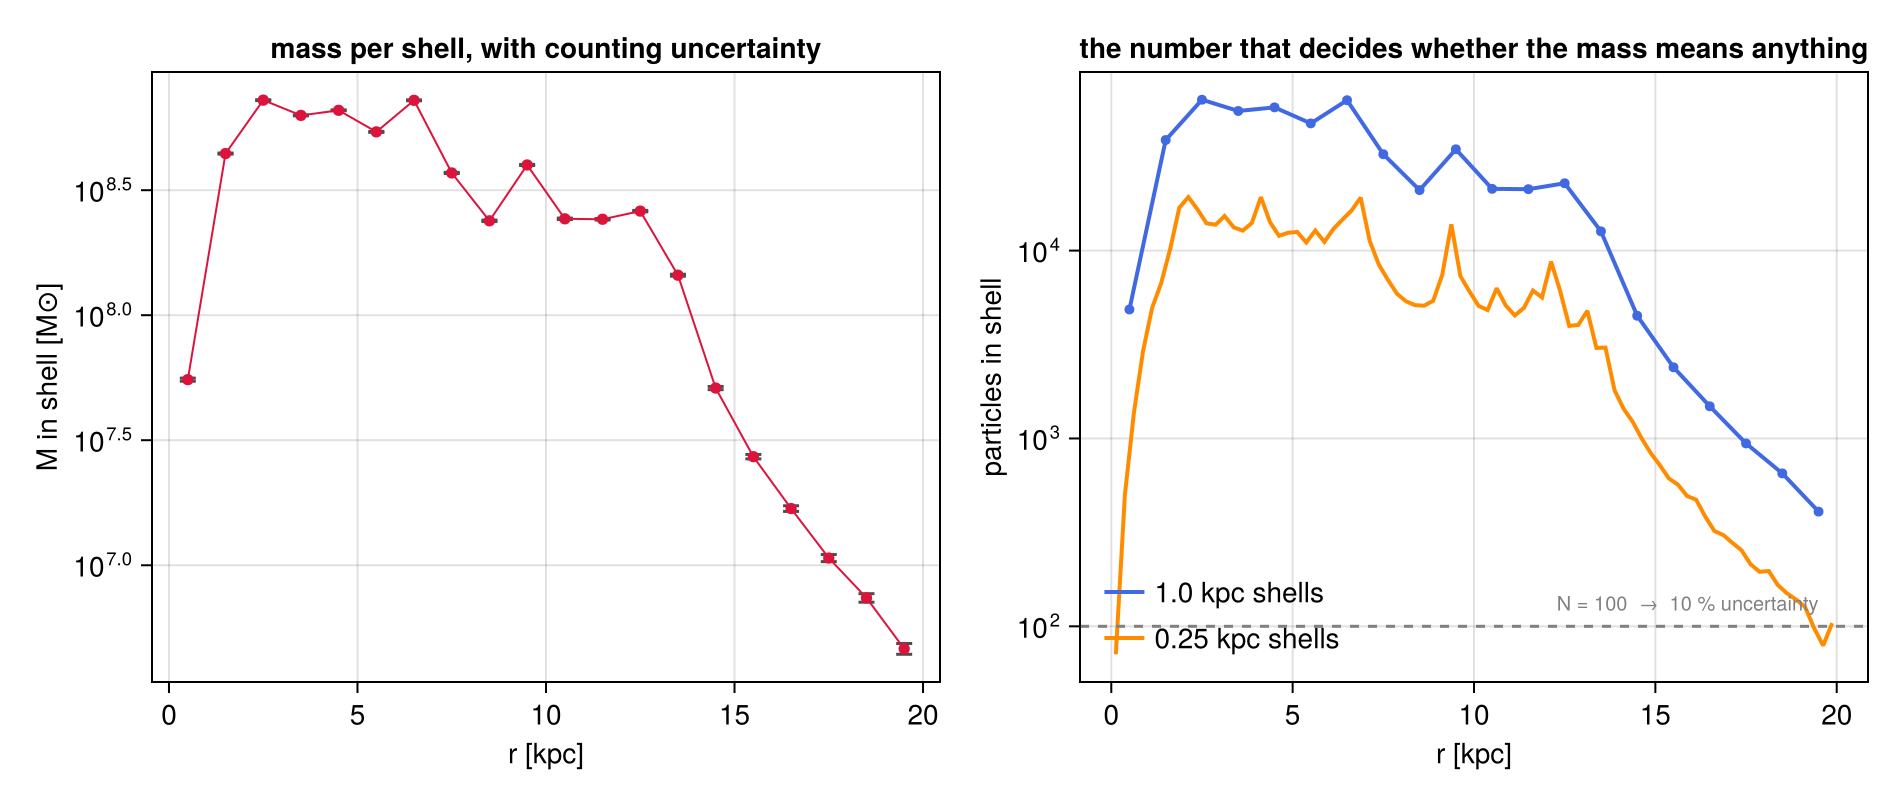

In [5]:
edges = collect(0.0:1.0:20.0)
rows = NamedTuple[]
for i in 1:length(edges)-1
    reg = i == 1 ? Sphere(edges[2]) : SphericalShell(edges[i], edges[i+1])
    sh = subregion(stars, reg, verbose=false)
    n  = length(sh.data)
    m  = n == 0 ? 0.0 : msum(sh, :Msol)
    push!(rows, (r=(edges[i]+edges[i+1])/2, n=n, m=m, err=n == 0 ? NaN : 100/sqrt(n)))
end

# the same walk with shells four times thinner — same regions, a quarter of the count
rt, nt = Float64[], Int[]
for r0 in 0.0:0.25:19.75
    reg = r0 == 0 ? Sphere(0.25) : SphericalShell(r0, r0 + 0.25)
    push!(rt, r0 + 0.125)
    push!(nt, length(subregion(stars, reg, verbose=false).data))
end

println(rpad("shell [kpc]", 14), rpad("N", 9), rpad("M [Msol]", 13), "≈ 1/√N")
println("-"^46)
for t in rows[1:2:end]
    println(rpad(string(t.r - 0.5, " – ", t.r + 0.5), 14), rpad(t.n, 9),
            rpad(round(t.m, sigdigits=4), 13),
            isnan(t.err) ? "—" : string(round(t.err, digits=1), " %"))
end
println()
println("thinnest bin, 1.00 kpc shells : N = ", minimum(rows[i].n for i in 1:length(rows)),
        "  →  ", round(100/sqrt(minimum(t.n for t in rows)), digits=1), " %")
println("thinnest bin, 0.25 kpc shells : N = ", minimum(nt),
        "  →  ", round(100/sqrt(max(minimum(nt), 1)), digits=1), " %")


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(950, 400))
ax1 = Axis(fig[1, 1], xlabel="r [kpc]", ylabel="M in shell [M⊙]", yscale=log10,
           title="mass per shell, with counting uncertainty")
rr  = [t.r for t in rows]; mm = [max(t.m, 1e3) for t in rows]
ee  = min.([isnan(t.err) ? 0.0 : t.err/100 for t in rows] .* mm, 0.9 .* mm)
errorbars!(ax1, rr, mm, ee; whiskerwidth=8, color=:grey30)
scatter!(ax1, rr, mm; color=:crimson, markersize=8)
lines!(ax1, rr, mm; color=:crimson, linewidth=1)

ax2 = Axis(fig[1, 2], xlabel="r [kpc]", ylabel="particles in shell", yscale=log10,
           title="the number that decides whether the mass means anything")
lines!(ax2, rr, [max(t.n, 1) for t in rows]; color=:royalblue, linewidth=2,
       label="1.0 kpc shells")
scatter!(ax2, rr, [max(t.n, 1) for t in rows]; color=:royalblue, markersize=7)
lines!(ax2, rt, max.(nt, 1); color=:darkorange, linewidth=2, label="0.25 kpc shells")
hlines!(ax2, [100.]; color=:grey, linestyle=:dash)
text!(ax2, 19.5, 115; text="N = 100  →  10 % uncertainty", color=:grey, fontsize=10,
      align=(:right, :bottom))
axislegend(ax2; position=:lb, framevisible=false)
fig


Inside 6 kpc each shell holds tens of thousands of particles and the mass is
good to a fraction of a percent. Even the outermost 1-kpc shell still holds a
few hundred, so this particular profile is trustworthy at the few-percent
level everywhere — which is worth stating plainly, because the interesting
part is that you could not have known it without looking.

Now halve the bin width twice. The orange curve is exactly the same sweep in
0.25 kpc shells: identical regions, identical arithmetic, a quarter of the
particles per point, and the outer bins cross into double-digit uncertainty.
Nothing about the selection changed — only how finely it was sliced.

The practical rule is therefore to choose bin widths by *count*, not by
appearance. Equal-width bins look tidy and concentrate all the noise in the
outermost points; widen the outer shells until they hold enough particles, and
quote $N$ next to every value. The [hydro page's](03_hydro_Get_Subregions.md)
advice about boundary treatment has no analogue here — this is its
replacement.


## 4. The Geometry Gallery

Every region value type applies to particles, with the same keywords:
`center`, `range_unit`, `inverse=true` for the complement, and `axis` to tilt
a cylinder or a cylindrical shell. Only the boundary machinery is absent —
`split`, `nsub`, `refine`, `refine_to` have nothing to act on, since a point
has no volume to divide.


Cuboid — a slab               413099   

81.2 % of the stellar mass
Cylinder(8, 2)                

358054   70.3 % of the stellar mass
Sphere(6)                     268097   

52.6 % of the stellar mass
SphericalShell(6, 10)         151432   29.8 % of the stellar mass
CylindricalShell(6, 10, 2)    145216   

28.6 % of the stellar mass
Cylinder(8, 2) tilted 40°     229964   45.2 % of the stellar mass


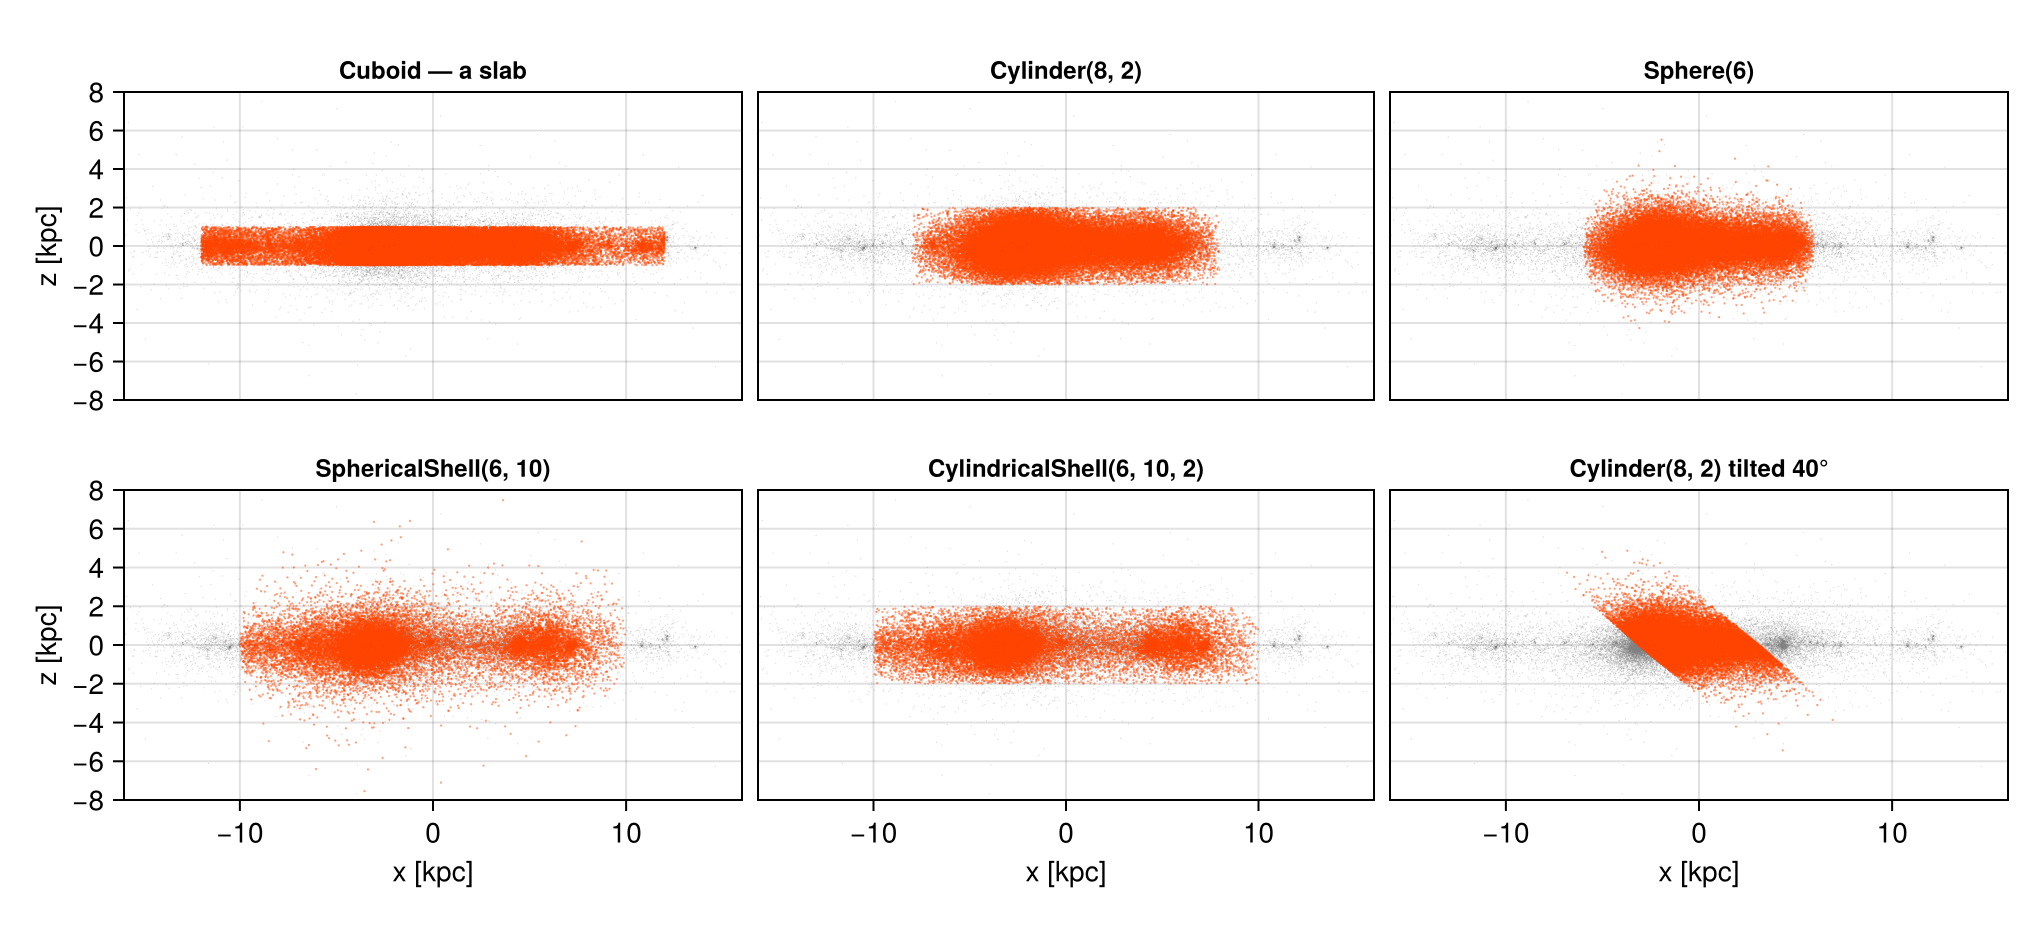

In [6]:
gallery = [
    ("Cuboid — a slab",            Cuboid(xrange=[-12, 12], yrange=[-12, 12], zrange=[-1, 1])),
    ("Cylinder(8, 2)",             Cylinder(8., 2.)),
    ("Sphere(6)",                  Sphere(6.)),
    ("SphericalShell(6, 10)",      SphericalShell(6., 10.)),
    ("CylindricalShell(6, 10, 2)", CylindricalShell(6., 10., 2.)),
    ("Cylinder(8, 2) tilted 40°",  Cylinder(8., 2.; axis=[sind(40), 0, cosd(40)])),
]
for (name, reg) in gallery
    s = subregion(stars, reg, verbose=false)
    println(rpad(name, 30), rpad(length(s.data), 9),
            round(100*msum(s, :Msol)/msum(stars, :Msol), digits=1), " % of the stellar mass")
end


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1020, 470))
xa, ya, za = pos(stars)
for (k, (name, reg)) in enumerate(gallery)
    s = subregion(stars, reg, verbose=false)
    x, y, z = pos(s)
    row, col = fld(k-1, 3)+1, mod(k-1, 3)+1
    ax = Axis(fig[row, col], title=name, titlesize=12,
              xlabel=(row == 2 ? "x [kpc]" : ""), ylabel=(col == 1 ? "z [kpc]" : ""))
    scatter!(ax, xa[1:20:end], za[1:20:end]; color=(:grey, 0.25), markersize=1)
    scatter!(ax, x[1:5:end], z[1:5:end]; color=(:orangered, 0.5), markersize=1.6)
    limits!(ax, -16, 16, -8, 8); ax.aspect = DataAspect()
    row == 2 || hidexdecorations!(ax; grid=false)
    col == 1 || hideydecorations!(ax; grid=false)
end
rowgap!(fig.layout, 4); colgap!(fig.layout, 8)
fig


Every panel is the same edge-on view of the same population; grey is
everything, orange is what the region kept. The tilted cylinder is the one to
look at twice — `axis=[sin 40°, 0, cos 40°]` rotates the selection, not the
data, which is what makes it usable on a warped or inclined disc.


## 5. Composites and the `@region` Block

Boolean composition — `∩` `∪` `\` `!`, or `intersect` / `union` / `setdiff` if
you prefer ASCII — behaves exactly as on the grid, and `@region` hoists the
shared keywords out of a composite so the shapes stay readable.

`∪` is typed in the Julia REPL and in VS Code as `\cup` followed by TAB;
`∩` is `\cap`+TAB. The named functions are always available as an alternative.


In [7]:
halo_no_disc = @region unit=:kpc center=[:bc] begin
    inner = Sphere(15)
    disc  = Cylinder(15, 2)
    inner \ disc            # spheroid minus the disc slab: the "off-plane" stars
end

s_halo = subregion(stars, halo_no_disc, verbose=false)
s_disc = subregion(stars, Cylinder(15., 2.), verbose=false)
s_ball = subregion(stars, Sphere(15.), verbose=false)

println("Sphere(15)                 : ", rpad(length(s_ball.data), 9),
        round(msum(s_ball, :Msol), sigdigits=5), " Msol")
println("  ∩ disc slab              : ", rpad(length(s_disc.data), 9),
        round(msum(s_disc, :Msol), sigdigits=5))
println("  minus the slab (@region) : ", rpad(length(s_halo.data), 9),
        round(msum(s_halo, :Msol), sigdigits=5))
println()
println("off-plane fraction of the inner stellar mass : ",
        round(100*msum(s_halo, :Msol)/msum(s_ball, :Msol), digits=1), " %")
println("counts partition exactly : ",
        length(s_halo.data) + length(subregion(s_ball, Cylinder(15., 2.), verbose=false).data)
        == length(s_ball.data))


Sphere(15)                 : 502097   

5.7267e9 Msol
  ∩ disc slab              : 489072   5.5788e9
  minus the slab (@region) : 13101    1.4881e8

off-plane fraction of the inner stellar mass : 2.6 %
counts partition exactly : true


The last line is the particle version of the hydro page's ledger check, and it
is worth making a habit of: a composite and its complement, applied to the
same parent, must reproduce the parent's count. On a grid that identity holds
because fractions are complementary; here it holds because membership is a
predicate. Either way, if it fails, the region is not describing what you
think it describes.

Note also that `subregion` chains — `subregion(s_ball, Cylinder(...))` narrows
an already-selected object, because the return value is a full particle object
of the same type.


## 6. Place *and* State: Regions Meet Filters

A region answers *where*. `filterdata` answers *what*: it selects on the value
of any `getvar` quantity — age, speed, angular momentum, anything derived —
and returns the same kind of object, so the two compose in either order.

Stars carry a birth time, so "young" and "old" are one condition away. The
same annulus, split by age, is two very different objects.


In [8]:
annulus = CylindricalShell(4., 12., 2.)          # the star-forming disc, minus the nucleus

ring   = subregion(stars, annulus, verbose=false)
young  = filterdata(ring, Below(:age, 50, unit=:Myr), verbose=false)
old    = filterdata(ring, Above(:age, 300,  unit=:Myr), verbose=false)

# order does not matter: filter first, then cut
young2 = subregion(filterdata(stars, Below(:age, 50, unit=:Myr), verbose=false),
                   annulus, verbose=false)

println("annulus 4–12 kpc, |z| < 2 : ", rpad(length(ring.data), 9),
        round(msum(ring, :Msol), sigdigits=5), " Msol")
println("  younger than 50 Myr    : ", rpad(length(young.data), 9),
        round(msum(young, :Msol), sigdigits=5))
println("  older than 300 Myr        : ", rpad(length(old.data), 9),
        round(msum(old, :Msol), sigdigits=5))
println()
println("region∘filter == filter∘region : ", length(young.data) == length(young2.data))


annulus 4–12 kpc, |z| < 2 : 286724   

3.2728e9 Msol
  younger than 50 Myr    : 45119    5.2864e8
  older than 300 Myr        : 65342    7.4213e8

region∘filter == filter∘region : true


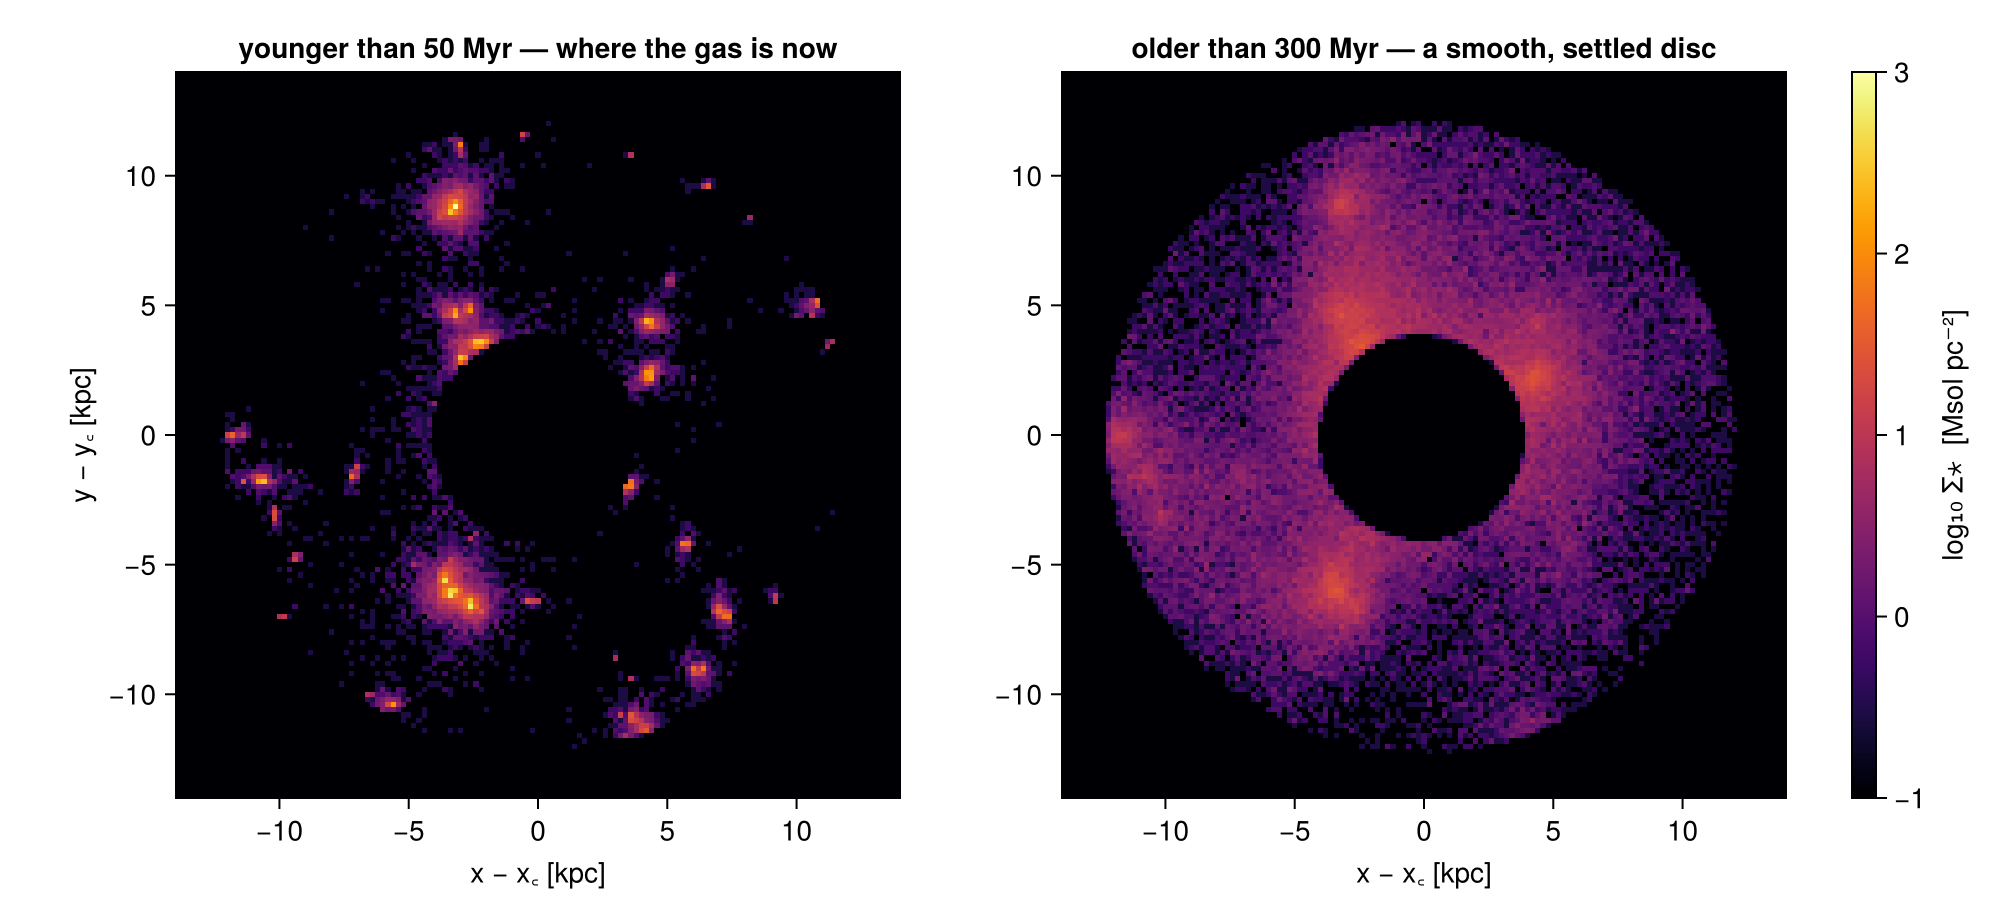

In [9]:
p_young = sproj(young)
p_old   = sproj(old)


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1000, 460))
ax1 = Axis(fig[1, 1], title="younger than 50 Myr — where the gas is now",
           xlabel="x − x꜀ [kpc]", ylabel="y − y꜀ [kpc]")
show_sd!(ax1, p_young; decorate=true); limits!(ax1, -14, 14, -14, 14)
ax2 = Axis(fig[1, 2], title="older than 300 Myr — a smooth, settled disc",
           xlabel="x − x꜀ [kpc]")
show_sd!(ax2, p_old; decorate=true); limits!(ax2, -14, 14, -14, 14)
sd_bar!(fig[1, 3])
fig


Same region, same units, same colour scale — and two different galaxies. The
young population traces the structure the gas has *right now*: clumpy, knotted,
concentrated where star formation is happening. The old population has had time
to phase-mix into a smooth axisymmetric disc.

That contrast is only visible because the geometric cut and the value cut are
independent operations on the same object. The
[Masking & Filtering page](05_multi_Masking_Filtering.md) treats the value side
in full, including how to combine conditions with `&`, `|`, and `!`.


## 7. Profiles That Regions Make Easy

Two profiles, both built the same way: a stack of `CylindricalShell` annuli,
each one a region, each one asked for a mass-weighted mean.

The first is rotation. Young stars inherit the near-circular orbits of the gas
they formed from; old stars have been scattered, and a scattered population
lags — its mean azimuthal speed falls below the circular speed by an amount
that grows with its velocity dispersion. That is *asymmetric drift*, and it is
one of the cleanest things a region stack can show.


at 7.5 kpc :  young 191.2

 km/s (N=2396)   old 166.7 km/s (N=7878)


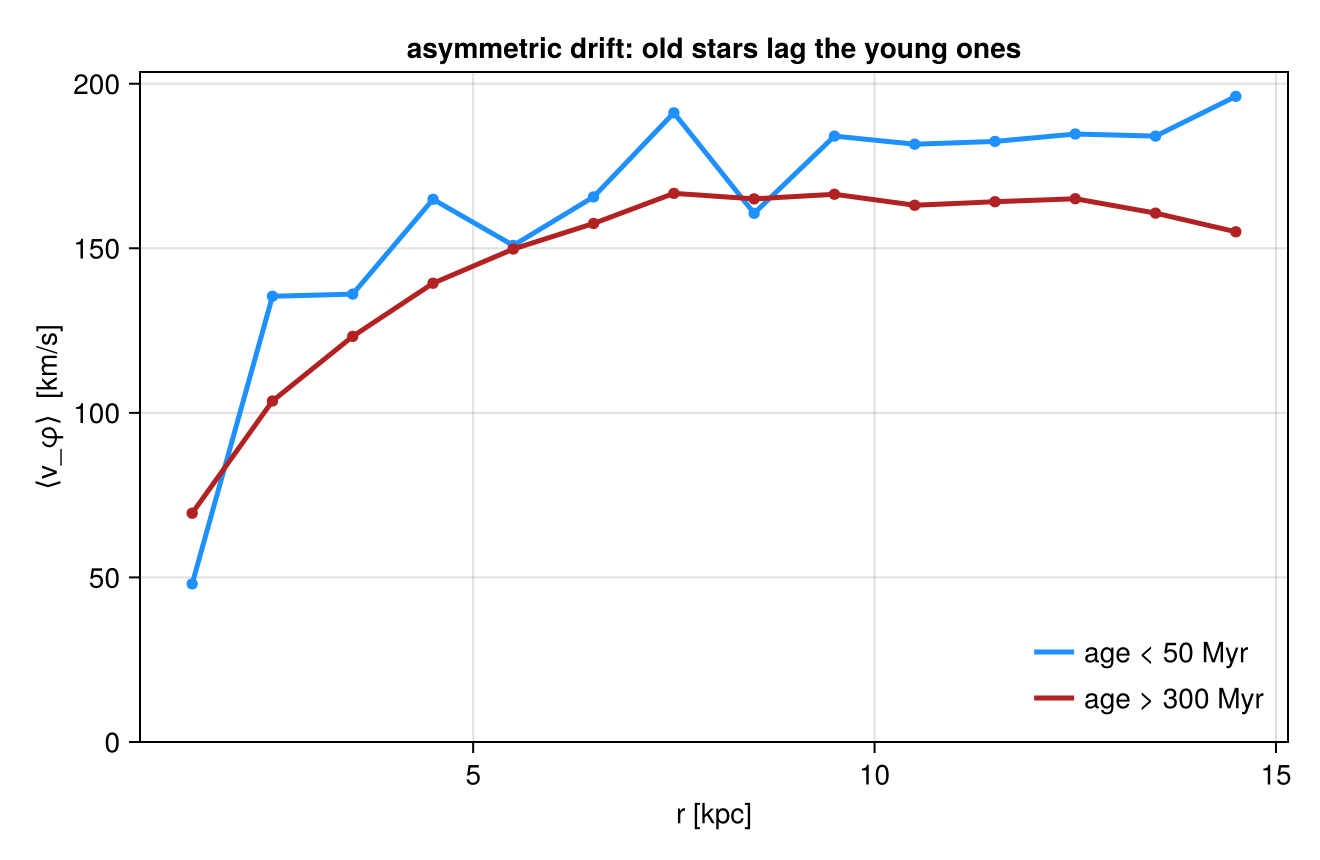

In [10]:
r_ann = collect(1.5:1.0:14.5)
vy, vo, ny, no = Float64[], Float64[], Int[], Int[]
for r in r_ann
    a  = subregion(stars, CylindricalShell(r-0.5, r+0.5, 2.), verbose=false)
    ay = filterdata(a, Below(:age, 50,   unit=:Myr), verbose=false)
    ao = filterdata(a, Above(:age, 300,  unit=:Myr), verbose=false)
    for (obj, v, n) in ((ay, vy, ny), (ao, vo, no))
        k = length(obj.data)
        push!(n, k)
        if k > 0
            m = getvar(obj, :mass, :Msol)
            push!(v, sum(getvar(obj, :vϕ_cylinder, :km_s, center=[:bc]) .* m) / sum(m))
        else
            push!(v, NaN)
        end
    end
end
println("at 7.5 kpc :  young ", round(vy[findfirst(==(7.5), r_ann)], digits=1),
        " km/s (N=", ny[findfirst(==(7.5), r_ann)], ")   old ",
        round(vo[findfirst(==(7.5), r_ann)], digits=1),
        " km/s (N=", no[findfirst(==(7.5), r_ann)], ")")


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(660, 430))
ax = Axis(fig[1, 1], xlabel="r [kpc]", ylabel="⟨v_φ⟩  [km/s]",
          title="asymmetric drift: old stars lag the young ones")
lines!(ax, r_ann, vy; color=:dodgerblue, linewidth=2.5, label="age < 50 Myr")
scatter!(ax, r_ann, vy; color=:dodgerblue, markersize=8)
lines!(ax, r_ann, vo; color=:firebrick, linewidth=2.5, label="age > 300 Myr")
scatter!(ax, r_ann, vo; color=:firebrick, markersize=8)
axislegend(ax; position=:rb, framevisible=false)
ylims!(ax, 0, nothing)
fig


The gap between the two curves is the drift: about 25 km/s at 7.5 kpc, where
the young stars are turning at 191 km/s and the older ones at 167. It is a
real dynamical measurement, and it came from a stack of annuli and one age
condition.

The second profile is vertical structure. The same age split, now measured
perpendicular to the disc: a young population should be thin because it has
not been heated yet.


RMS height, age < 50 Myr : 0.295 kpc  (N=68020)
RMS height, age > 300 Myr   : 0.871 kpc  (N=103448)


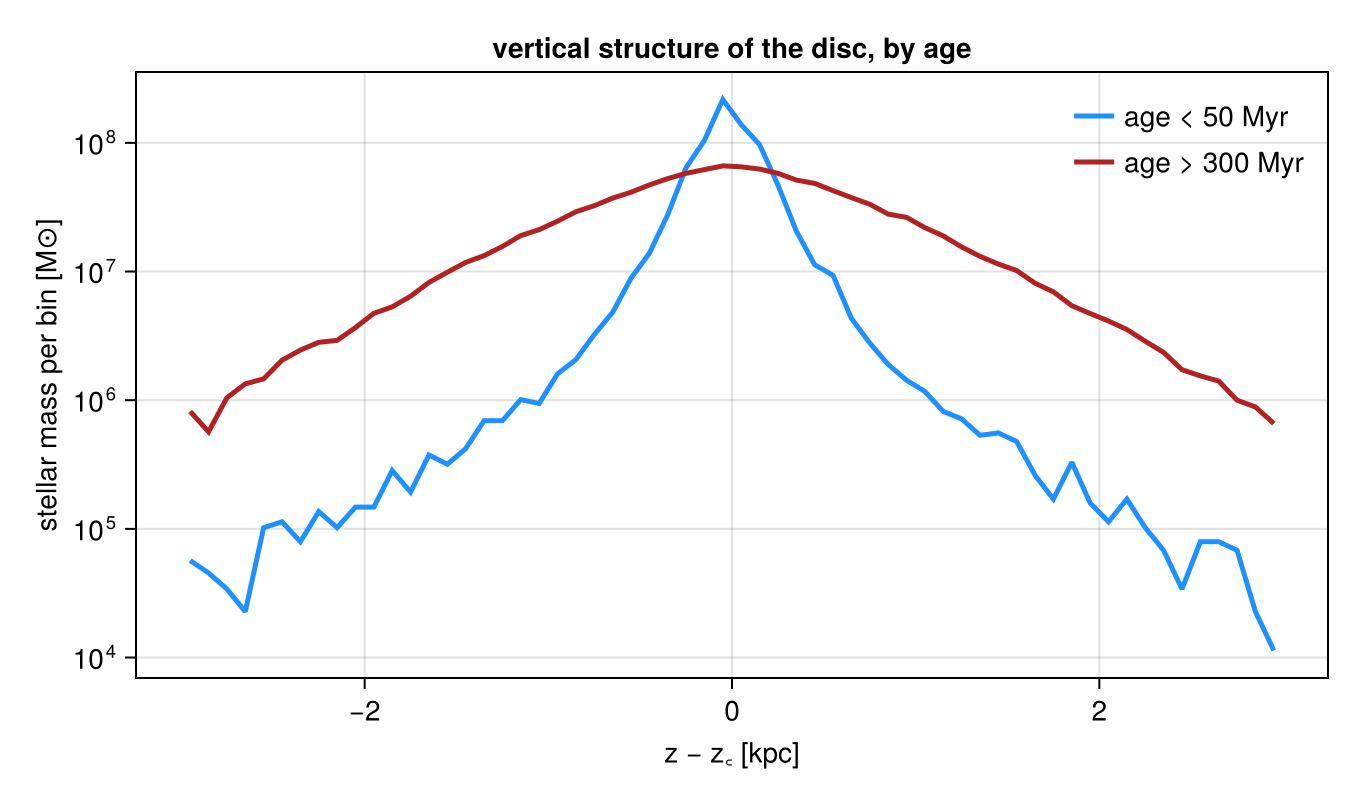

In [11]:
disc  = subregion(stars, Cylinder(12., 3.), verbose=false)
dyoung = filterdata(disc, Below(:age, 50,   unit=:Myr), verbose=false)
dold   = filterdata(disc, Above(:age, 300,  unit=:Myr), verbose=false)

# mass-weighted RMS height — one number per population
function zrms(o)
    z = getvar(o, :z, :kpc, center=[:bc]); m = getvar(o, :mass, :Msol)
    sqrt(sum(m .* z.^2) / sum(m))
end
println("RMS height, age < 50 Myr : ", round(zrms(dyoung), digits=3), " kpc  (N=",
        length(dyoung.data), ")")
println("RMS height, age > 300 Myr   : ", round(zrms(dold), digits=3), " kpc  (N=",
        length(dold.data), ")")


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(680, 400))
ax = Axis(fig[1, 1], xlabel="z − z꜀ [kpc]", ylabel="stellar mass per bin [M⊙]",
          yscale=log10, title="vertical structure of the disc, by age")
for (o, c, l) in ((dyoung, :dodgerblue, "age < 50 Myr"), (dold, :firebrick, "age > 300 Myr"))
    z = getvar(o, :z, :kpc, center=[:bc]); m = getvar(o, :mass, :Msol)
    bins = range(-3, 3; length=61); mid = (bins[1:end-1] .+ bins[2:end]) ./ 2
    h = [sum(m[(z .>= bins[i]) .& (z .< bins[i+1])]) for i in 1:length(bins)-1]
    lines!(ax, mid, max.(h, 1e3); color=c, linewidth=2.5, label=l)
end
axislegend(ax; position=:rt, framevisible=false)
fig


A factor of three in RMS height between the two populations — 0.3 kpc against
0.87 kpc — in the same cylinder, from the same three lines of selection code.
Stars are born in a thin gas layer and are scattered out of it afterwards, and
a few hundred Myr is already enough to see it happen. The young profile is
also visibly noisier in its wings: the counting story of §3, showing up again
where the population thins out.


## 8. Reference: the Classic Symbol API

The symbol-based interface works on particle data unchanged and remains the
quickest way to take an exploratory cut.

| Value type | Classic call |
|:--|:--|
| `Cuboid(xrange=…, yrange=…, zrange=…)` | `subregion(stars, :cuboid; xrange=…, …)` |
| `Sphere(R)` | `subregion(stars, :sphere; radius=R)` |
| `Cylinder(R, H)` | `subregion(stars, :cylinder; radius=R, height=H)` (z-axis only) |
| `SphericalShell(rin, rout)` | `shellregion(stars, :sphere; radius=[rin, rout])` |
| `CylindricalShell(rin, rout, H)` | `shellregion(stars, :cylinder; radius=[rin, rout], height=H)` |

Shared keywords: `center`, `range_unit`, `inverse=true`. The `cell` and
`split` keywords of the grid interfaces have no meaning for points and are
simply absent — which is why the classic and value-type selections agree
exactly here, unlike on the hydro side.


In [12]:
classic = subregion(stars, :sphere; radius=10., center=[:bc], range_unit=:kpc, verbose=false)
value_t = subregion(stars, Sphere(10.), verbose=false)

println("classic :sphere  : ", rpad(length(classic.data), 9), round(msum(classic, :Msol), sigdigits=8))
println("value-type Sphere: ", rpad(length(value_t.data), 9), round(msum(value_t, :Msol), sigdigits=8))
println("identical        : ", length(classic.data) == length(value_t.data) &&
                               msum(classic, :Msol) == msum(value_t, :Msol))


classic :sphere  : 419529   

4.7852795e9
value-type Sphere: 419529   4.7852795e9
identical        : true


## 9. Practical Guidance

**Quote $N$ with every number.** The selection is exact; the estimate built
from it is not. A mass, a mean velocity, or a dispersion from a region is only
as good as the count inside it, and $1/\sqrt{N}$ is the floor (§3).

**Bin by count, not by looks.** Equal-width annuli look tidy and put all the
noise in the outermost points. Widen the outer bins until they hold enough
particles.

**Regions chain, and they commute with filters.** `subregion` returns a full
object, so cuts compose in any order and can be interleaved with `filterdata`
(§6). Use that to keep each step meaning one thing.

**Check partitions.** A region plus its complement must reproduce the parent's
count exactly. It is one line, it is free, and it catches a mis-specified
centre or unit immediately (§2, §5).

**`split`, `nsub`, `refine_to` do not apply.** They are grid concepts. If you
find yourself reaching for them on particles, the question you actually have is
probably about counts.

**Give `getvar` the same `center` as the region.** Derived quantities like
`:vϕ_cylinder`, `:r_cylinder`, and `:z` are measured about `getvar`'s own
`center`, which defaults to the box corner — a different argument from the
region's. See §4 of the [gravity page](03_gravity_Get_Subregions.md) for what
that costs when it is forgotten.


## Summary

- For particles a region is a membership test, not a boundary treatment: no
  `:fraction`, no `split`, and `msum` over a selection is exact by
  construction. Partitions close to the last floating-point bit (§2).
- The error that matters is statistical. Shell masses inherit a $1/\sqrt{N}$
  uncertainty, which is what actually limits a profile's outer points (§3).
- All region value types, boolean composition, `@region`, tilted axes, and
  `inverse=true` work exactly as on the grid (§4, §5).
- Geometric selection and value filtering are independent and commute, which
  makes population splits — young vs old, fast vs slow — a one-line
  refinement of any region (§6).
- Stacks of annuli turn regions into profiles: asymmetric drift and the
  age–scale-height relation both fall out of a dozen region objects (§7).

**Continue with:**

- [Hydro sub-regions](03_hydro_Get_Subregions.md) — exact splitting, region
  algebra, and mass budgets on the grid.
- [Gravity sub-regions](03_gravity_Get_Subregions.md) — the same regions
  applied to the force field, and the mass this galaxy's stars do not account
  for.
- [Clumps sub-regions](03_clumps_Get_Subregions.md) — regions applied to a
  catalogue of extended objects represented by their peaks.
- [Masking & Filtering](05_multi_Masking_Filtering.md) — the value-space
  counterpart of this page.
